# Unit09_Example_02 | 化工案例二：非恆溫柱塞型反應器（PFR）溫度與轉化率分布

本 Notebook 使用 `scipy.integrate.solve_ivp()` 搭配 `method='RK45'` 求解**非恆溫柱塞型反應器（PFR）** 中丙酮裂解反應的多變數 IVP ODE，探討轉化率與溫度沿反應器軸向的分布，以及外部熱交換溫度對反應器性能的影響。

## 目標
- 建立 PFR 物料平衡與能量平衡之耦合常微分方程式（以體積 $V$ 為獨立變數）
- 使用 `solve_ivp(method='RK45')` 求解多變數 IVP ODE
- 繪製轉化率 $X(V)$ 與溫度 $T(V)$ 沿反應器軸向之分布圖
- 探討外部熱交換流體溫度 $T_a$ 對反應器轉化率與溫度分布的敏感度
- 比較有熱交換與絕熱操作條件下的反應器性能差異

## 目錄
- [0. 環境設定](#0)
- [1. 載入套件](#1)
- [2. 問題描述](#2)
- [3. 基準案例模擬](#3)
- [4. 熱交換溫度敏感度分析](#4)
- [5. 絕熱操作比較與課程總結](#5)

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit09_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit09'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit09
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_02\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.integrate import solve_ivp

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述

#### 2.1 化工背景

**柱塞型反應器（PFR，Plug Flow Reactor）** 是化工製程中常見的連續式管式反應器。在理想平推流假設下，流體沿管軸方向流動，不存在軸向混合，反應物濃度與溫度均沿管長（或反應器體積）而連續變化。

本範例考慮**丙酮氣相裂解反應（Acetone Pyrolysis）**：

$$
\text{CH}_3\text{COCH}_3 \xrightarrow{\Delta} \text{CH}_2\text{CO} + \text{CH}_4 \quad \text{（A → B + C）}
$$

- 丙酮（A）→ 乙烯酮（B, Ketene）+ 甲烷（C）
- **一階不可逆氣相反應**，反應為**吸熱反應**（ $\Delta H_{rx} > 0$ ）
- 需要外部加熱以維持反應進行

反應器外部設有熱交換套管，以高溫流體（溫度 $T_a$ ）持續加熱反應管。探討不同 $T_a$ 值對轉化率與溫度軸向分布的影響，是本範例的核心目標。

> **文獻來源：** Fogler, H. S. (2016). *Elements of Chemical Reaction Engineering*, 5th ed., Prentice Hall.

---

#### 2.2 數學模型

**獨立變數**：反應器體積 $V$ （ $\mathrm{m^3}$ ）， $V \in [0, V_{max}]$

**狀態變數**：
- $X$ ：丙酮的轉化率（dimensionless， $0 \leq X < 1$ ）
- $T$ ：反應器溫度（K）

##### 物料平衡（Mole Balance）

$$
\frac{dX}{dV} = \frac{-r_A}{F_{A0}}
$$

其中反應速率（以丙酮為基準）：

$$
-r_A = k(T)\,C_A = k(T)\,C_{A0}\,\frac{(1-X)\,T_0}{(1+X)\,T}
$$

- $k(T) = k_0 \exp\!\left[E_R\!\left(\dfrac{1}{T_0}-\dfrac{1}{T}\right)\right]$ ：一階速率常數（ $\mathrm{s^{-1}}$ ）
- $C_{A0} = P_0/(R\,T_0)$ ：進口丙酮濃度（ $\mathrm{mol/m^3}$ ）
- 氣相體積流量隨轉化率與溫度改變： $v = v_0\,(T/T_0)\,(1+X)$ ，故 $C_A = C_{A0}(1-X)T_0/[(1+X)T]$

##### 能量平衡（Energy Balance）

$$
\frac{dT}{dV} = \frac{U_a\,(T_a - T) + (-\Delta H_{rx})\,(-r_A)}{F_{A0}\,\tilde{C}_{pm}}
$$

其中混合熱容量（隨轉化率線性變化）：

$$
\tilde{C}_{pm} = C_{pA} + X\,\Delta C_p = 163 - 9\,X \quad [\mathrm{J/(mol {\cdot} K)}]
$$

- $\Delta C_p = C_{pB} + C_{pC} - C_{pA} = 83 + 71 - 163 = -9$ J/(mol·K)
- $U_a$ ：體積熱傳係數（ $\mathrm{J/(m^3 {\cdot} s {\cdot} K)}$ ）

---

#### 2.3 系統參數

| 參數 | 符號 | 數值 | 單位 | 說明 |
|------|------|------|------|------|
| 入口溫度 | $T_0$ | 1035 | K | 丙酮進料溫度 |
| 操作壓力 | $P_0$ | 162,000 | Pa | 系統壓力（≈1.6 atm）|
| 丙酮進料流率 | $F_{A0}$ | 0.0376 | mol/s | |
| 反應管直徑 | $D$ | 0.01 | m | |
| 反應管長度 | $L$ | 1.8 | m | |
| 速率常數（ $T_0$ ）| $k_0$ | 3.58 | $\mathrm{s^{-1}}$ | |
| 活化能（ $E/R$ ）| $E_R$ | 34,222 | K | |
| 反應熱（吸熱）| $\Delta H_{rx}$ | 80,770 | J/mol | 正值（吸熱）|
| 熱容量（丙酮 A）| $C_{pA}$ | 163 | J/(mol·K) | |
| 熱容量（乙烯酮 B）| $C_{pB}$ | 83 | J/(mol·K) | |
| 熱容量（甲烷 C）| $C_{pC}$ | 71 | J/(mol·K) | |
| 體積熱傳係數 | $U_a$ | 110.6 | $\mathrm{J/(m^3 {\cdot} s {\cdot} K)}$ | |
| 熱交換溫度（基準）| $T_a$ | 1250 | K | 靈敏度分析時變動 |


In [3]:
# ============================================================
# PFR 動態模型定義
# ============================================================
import numpy as np

# --- 基本常數 ---
R_gas = 8.314   # J/(mol·K) 氣體常數

# --- 系統參數 ---
T0   = 1035.0        # K    入口溫度
P0   = 162000.0      # Pa   操作壓力
FA0  = 0.0376        # mol/s 丙酮進料流率
D    = 0.01          # m    管徑
L    = 1.8           # m    管長

# 反應動力學
k0   = 3.58          # s⁻¹  T0 下的速率常數
E_R  = 34222.0       # K    活化能 / 氣體常數 (E/R)
dHrx = 80770.0       # J/mol 反應熱（正值 = 吸熱）

# 熱容量 [J/(mol·K)]
CpA  = 163.0         # 丙酮 (A)
CpB  = 83.0          # 乙烯酮 (B)
CpC  = 71.0          # 甲烷 (C)
dCp  = CpB + CpC - CpA   # = -9 J/(mol·K)

# 熱交換
Ua   = 110.6         # J/(m³·s·K) 體積熱傳係數
Ta   = 1250.0        # K    基準熱交換溫度

# --- 計算衍生參數 ---
Ac   = np.pi * D**2 / 4.0        # m²  截面積
Vmax = Ac * L                     # m³  最大反應器體積
CA0  = P0 / (R_gas * T0)         # mol/m³  入口丙酮濃度

print("PFR 系統參數：")
print(f"  管截面積 Ac   = {Ac:.4e} m²")
print(f"  反應器體積 Vmax = {Vmax:.4e} m³")
print(f"  入口濃度 CA0  = {CA0:.4f} mol/m³")
print(f"  dCp          = {dCp:.1f} J/(mol·K)")
print(f"\n反應動力學：")
print(f"  k(T0={T0}K) = {k0} s⁻¹")
print(f"  E/R          = {E_R} K")
print(f"  ΔHrx         = {dHrx} J/mol (吸熱)")


def pfr_ode(V, y, Ta=Ta, Ua=Ua):
    """
    非恆溫 PFR 耦合 ODE （丙酮裂解，氣相一階反應）

    獨立變數:
        V   : 反應器體積 (m³)

    狀態變數:
        y[0] = X : 丙酮轉化率 (dimensionless)
        y[1] = T : 反應器溫度 (K)

    返回:
        [dX/dV, dT/dV]
    """
    X, T = y

    # 防止數值溢出
    X = np.clip(X, 0.0, 0.9999)
    T = np.clip(T, 300.0, 3000.0)

    # 速率常數
    k = k0 * np.exp(E_R * (1.0/T0 - 1.0/T))

    # 丙酮濃度（氣相，考慮體積膨脹與溫度）
    CA = CA0 * (1.0 - X) * T0 / ((1.0 + X) * T)

    # 反應速率（正值 = 丙酮消耗速率）
    neg_rA = k * CA

    # 混合熱容量
    Cpm = CpA + X * dCp   # J/(mol·K)

    # 物料平衡
    dX_dV = neg_rA / FA0

    # 能量平衡
    dT_dV = (Ua * (Ta - T) + (-dHrx) * neg_rA) / (FA0 * Cpm)

    return [dX_dV, dT_dV]


print("\n✓ pfr_ode() 函式定義完成")

PFR 系統參數：
  管截面積 Ac   = 7.8540e-05 m²
  反應器體積 Vmax = 1.4137e-04 m³
  入口濃度 CA0  = 18.8263 mol/m³
  dCp          = -9.0 J/(mol·K)

反應動力學：
  k(T0=1035.0K) = 3.58 s⁻¹
  E/R          = 34222.0 K
  ΔHrx         = 80770.0 J/mol (吸熱)

✓ pfr_ode() 函式定義完成


---
### 3. 基準案例模擬

以基準熱交換溫度 $T_a = 1250$ K 為條件，從入口 $V=0$ （ $X=0$ ， $T=T_0=1035$ K）積分至 $V_{max}$ ，繪製：

1. **轉化率分布圖** $X(V)$ ：觀察丙酮轉化率沿反應器體積的增長情形
2. **溫度分布圖** $T(V)$ ：觀察溫度沿軸向的變化趨勢
3. **相圖** $(X, T)$ ：觀察轉化率與溫度的耦合變化軌跡

solver status : 0  (The solver successfully reached the end of the integration interval.)
積分步數      : 500
出口轉化率    : X(Vmax) = 0.0959
出口溫度      : T(Vmax) = 987.96 K


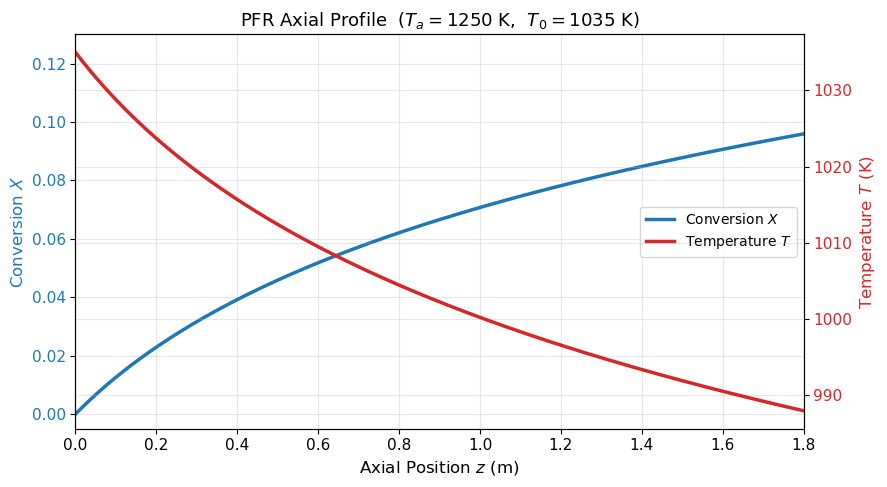

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_02\figs\fig01_axial_profile.png


In [8]:

# ============================================================
# 基準案例模擬（Ta = 1250 K）
# ============================================================

V_eval = np.linspace(0, Vmax, 500)
y0_base = [0.0, T0]   # X(0)=0, T(0)=T0

sol_base = solve_ivp(
    fun=lambda V, y: pfr_ode(V, y, Ta=1250.0),
    t_span=(0, Vmax),
    y0=y0_base,
    method='RK45',
    t_eval=V_eval,
    rtol=1e-8,
    atol=1e-10
)

print(f"solver status : {sol_base.status}  ({sol_base.message})")
print(f"積分步數      : {sol_base.t.shape[0]}")
print(f"出口轉化率    : X(Vmax) = {sol_base.y[0, -1]:.4f}")
print(f"出口溫度      : T(Vmax) = {sol_base.y[1, -1]:.2f} K")

# --- 換算軸向位置 z (m) = V / Ac ---
z_eval = V_eval / Ac

# ============================================================
# 圖 1: 轉化率與溫度軸向分布圖（雙 Y 軸）
# ============================================================
fig, ax1 = plt.subplots(figsize=(9, 5))

X_sol = sol_base.y[0]
T_sol = sol_base.y[1]

color_X = 'tab:blue'
color_T = 'tab:red'

ax1.plot(z_eval, X_sol, color=color_X, lw=2.5, label='Conversion $X$')
ax1.set_xlabel('Axial Position $z$ (m)')
ax1.set_ylabel('Conversion $X$', color=color_X)
ax1.tick_params(axis='y', labelcolor=color_X)
ax1.set_ylim(-0.005, 0.13)
ax1.set_xlim(0, L)

ax2 = ax1.twinx()
ax2.plot(z_eval, T_sol, color=color_T, lw=2.5, label='Temperature $T$')
ax2.set_ylabel('Temperature $T$ (K)', color=color_T)
ax2.tick_params(axis='y', labelcolor=color_T)

# Legend for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

ax1.set_title(f'PFR Axial Profile  ($T_a = 1250$ K,  $T_0 = {int(T0)}$ K)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_axial_profile.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔儲存：{FIG_DIR / 'fig01_axial_profile.png'}")


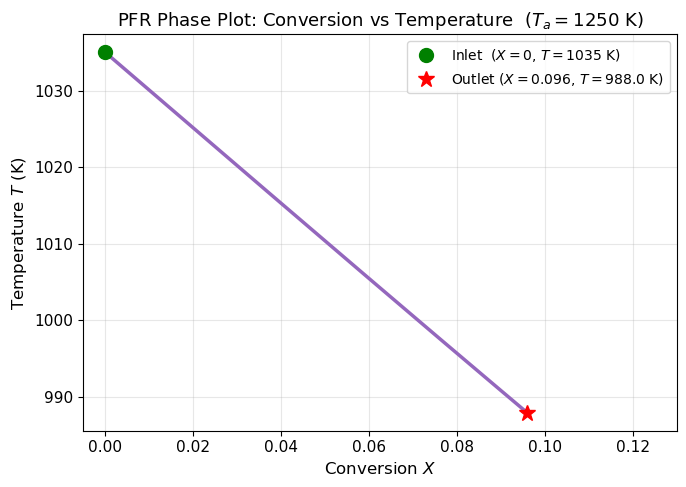

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_02\figs\fig02_phase_plot.png


In [9]:
# ============================================================
# 圖 2: (X, T) 相圖（Phase Plot）
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(X_sol, T_sol, color='tab:purple', lw=2.5)
ax.plot(X_sol[0], T_sol[0], 'go', ms=10, label=f'Inlet  ($X=0$, $T={int(T0)}$ K)')
ax.plot(X_sol[-1], T_sol[-1], 'r*', ms=12,
        label=f'Outlet ($X={X_sol[-1]:.3f}$, $T={T_sol[-1]:.1f}$ K)')

ax.set_xlabel('Conversion $X$')
ax.set_ylabel('Temperature $T$ (K)')
ax.set_title('PFR Phase Plot: Conversion vs Temperature  ($T_a = 1250$ K)')
ax.legend(fontsize=10)
ax.set_xlim(-0.005, 0.13)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_phase_plot.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔儲存：{FIG_DIR / 'fig02_phase_plot.png'}")

---
### 4. 熱交換溫度敏感度分析

改變外部熱交換溫度 $T_a \in \{1050,\,1150,\,1250,\,1350,\,1450\}$ K，重複求解 PFR ODE，比較：

- 不同 $T_a$ 下的**轉化率軸向分布** $X(z)$
- 不同 $T_a$ 下的**溫度軸向分布** $T(z)$

熱交換溫度越高，加熱越強烈，有助於克服吸熱反應的能量需求，提升轉化率。

  Ta (K)     X_out   T_out (K)
--------------------------------
    1050    0.0956      987.64
    1150    0.0957      987.80
    1250    0.0959      987.96
    1350    0.0961      988.12
    1450    0.0963      988.28


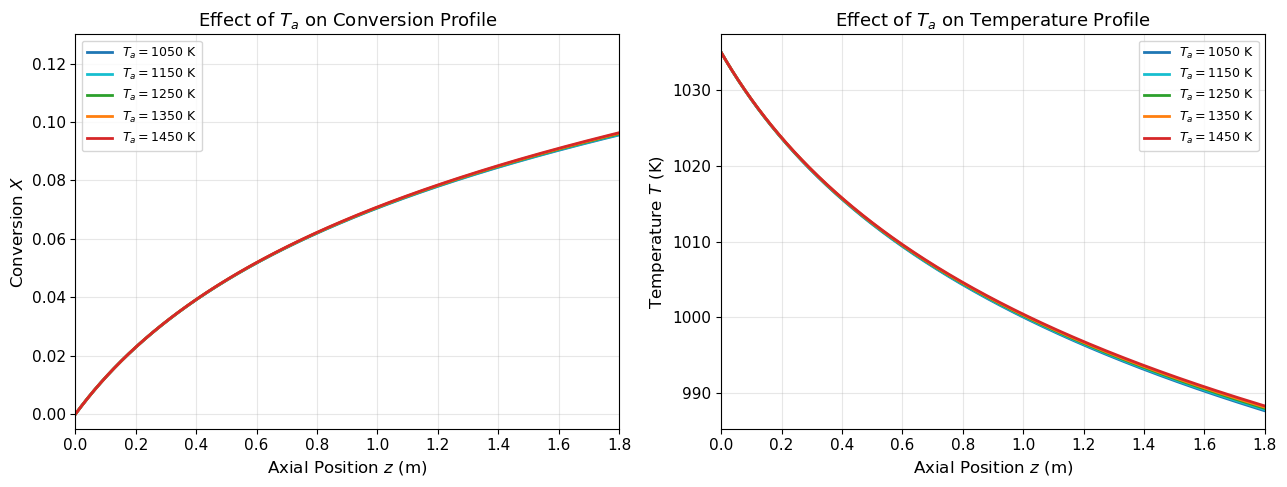


✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_02\figs\fig03_sensitivity_Ta.png


In [10]:
# ============================================================
# 熱交換溫度敏感度分析
# ============================================================

Ta_list   = [1050, 1150, 1250, 1350, 1450]   # K  熱交換溫度
colors    = ['tab:blue', 'tab:cyan', 'tab:green', 'tab:orange', 'tab:red']
y0_sens   = [0.0, T0]

fig, (ax_X, ax_T) = plt.subplots(1, 2, figsize=(13, 5))

print(f"{'Ta (K)':>8}  {'X_out':>8}  {'T_out (K)':>10}")
print("-" * 32)

results_summary = []

for Ta_val, col in zip(Ta_list, colors):
    sol = solve_ivp(
        fun=lambda V, y, _Ta=Ta_val: pfr_ode(V, y, Ta=_Ta),
        t_span=(0, Vmax),
        y0=y0_sens,
        method='RK45',
        t_eval=V_eval,
        rtol=1e-8, atol=1e-10
    )
    X_out = sol.y[0, -1]
    T_out = sol.y[1, -1]
    results_summary.append((Ta_val, X_out, T_out))
    print(f"{Ta_val:>8}  {X_out:>8.4f}  {T_out:>10.2f}")

    lbl = f'$T_a = {Ta_val}$ K'
    ax_X.plot(z_eval, sol.y[0], color=col, lw=2.0, label=lbl)
    ax_T.plot(z_eval, sol.y[1], color=col, lw=2.0, label=lbl)

# --- 標示基準 Ta 的出口點 ---
Ta_base_idx = Ta_list.index(1250)

# 轉化率圖
ax_X.set_xlabel('Axial Position $z$ (m)')
ax_X.set_ylabel('Conversion $X$')
ax_X.set_title('Effect of $T_a$ on Conversion Profile')
ax_X.set_xlim(0, L)
ax_X.set_ylim(-0.005, 0.13)
ax_X.legend(fontsize=9)

# 溫度圖
ax_T.set_xlabel('Axial Position $z$ (m)')
ax_T.set_ylabel('Temperature $T$ (K)')
ax_T.set_title('Effect of $T_a$ on Temperature Profile')
ax_T.set_xlim(0, L)
ax_T.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_sensitivity_Ta.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n✓ 圖檔儲存：{FIG_DIR / 'fig03_sensitivity_Ta.png'}")

---
### 5. 絕熱操作比較

**絕熱 PFR**（ $U_a = 0$ ）：無外部熱交換，反應熱全部由系統吸收。

由於丙酮裂解為**吸熱反應** $(\Delta H_{rx} > 0)$ ：
- 絕熱下，反應器溫度沿軸向**持續下降**（吸熱 → 降溫）
- 降溫使反應速率降低（Arrhenius 效應），轉化率增長趨緩
- 與有熱交換情形（持續加熱）形成鮮明對比

  操作模式        | X_out    |  T_out (K)
--------------------------------------------------
  有熱交換 Ta=1250K | 0.0959  |  987.96
  絕熱操作 Ua=0    | 0.0955  |  987.56


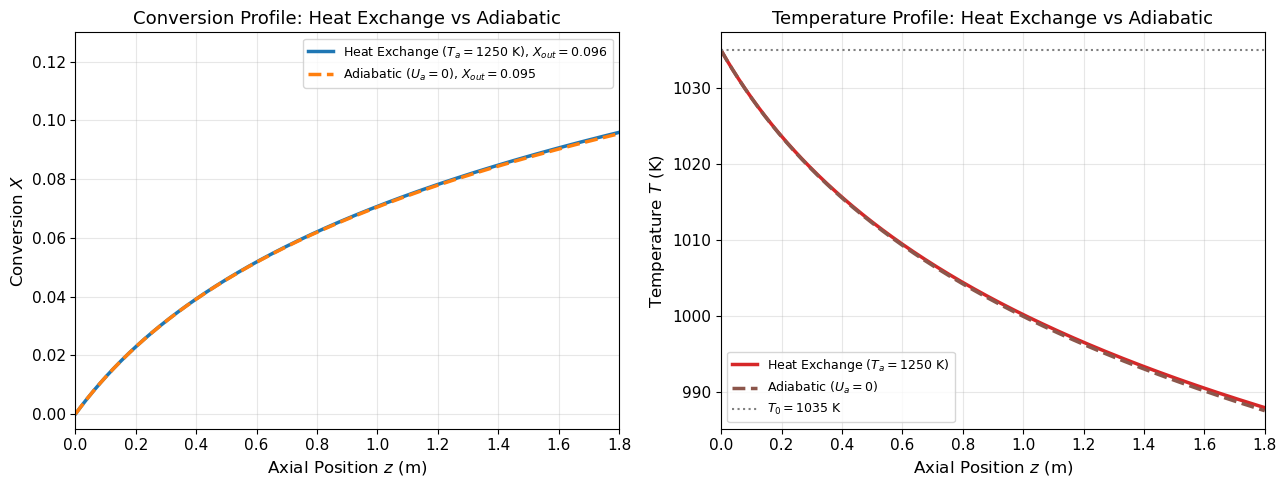

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_02\figs\fig04_adiabatic_vs_heatexchange.png


In [11]:

# ============================================================
# 絕熱操作 vs. 有熱交換操作（Ta=1250 K）比較
# ============================================================

# 絕熱：Ua = 0
sol_adiabatic = solve_ivp(
    fun=lambda V, y: pfr_ode(V, y, Ta=1250.0, Ua=0.0),
    t_span=(0, Vmax),
    y0=[0.0, T0],
    method='RK45',
    t_eval=V_eval,
    rtol=1e-8, atol=1e-10
)

print("=" * 50)
print("  操作模式        | X_out    |  T_out (K)")
print("-" * 50)
print(f"  有熱交換 Ta=1250K | {sol_base.y[0,-1]:.4f}  |  {sol_base.y[1,-1]:.2f}")
print(f"  絕熱操作 Ua=0    | {sol_adiabatic.y[0,-1]:.4f}  |  {sol_adiabatic.y[1,-1]:.2f}")
print("=" * 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- 轉化率比較 ---
ax1.plot(z_eval, sol_base.y[0],     color='tab:blue', lw=2.5,
         label=f'Heat Exchange ($T_a=1250$ K), $X_{{out}}={sol_base.y[0,-1]:.3f}$')
ax1.plot(z_eval, sol_adiabatic.y[0], color='tab:orange', lw=2.5, ls='--',
         label=f'Adiabatic ($U_a=0$), $X_{{out}}={sol_adiabatic.y[0,-1]:.3f}$')
ax1.set_xlabel('Axial Position $z$ (m)')
ax1.set_ylabel('Conversion $X$')
ax1.set_title('Conversion Profile: Heat Exchange vs Adiabatic')
ax1.set_xlim(0, L)
ax1.set_ylim(-0.005, 0.13)
ax1.legend(fontsize=9)

# --- 溫度比較 ---
ax2.plot(z_eval, sol_base.y[1],     color='tab:red', lw=2.5,
         label=f'Heat Exchange ($T_a=1250$ K)')
ax2.plot(z_eval, sol_adiabatic.y[1], color='tab:brown', lw=2.5, ls='--',
         label='Adiabatic ($U_a=0$)')
ax2.axhline(T0, color='gray', ls=':', lw=1.5, label=f'$T_0 = {int(T0)}$ K')
ax2.set_xlabel('Axial Position $z$ (m)')
ax2.set_ylabel('Temperature $T$ (K)')
ax2.set_title('Temperature Profile: Heat Exchange vs Adiabatic')
ax2.set_xlim(0, L)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_adiabatic_vs_heatexchange.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔儲存：{FIG_DIR / 'fig04_adiabatic_vs_heatexchange.png'}")


---
### 課程總結

#### 學習重點回顧

| 主題 | 說明 |
|------|------|
| **PFR 多變數 IVP ODE** | 物料平衡 $dX/dV$ + 能量平衡 $dT/dV$ 耦合，以 $V$ （反應器體積）為獨立變數 |
| **氣相體積膨脹修正** | $C_A = C_{A0}(1-X)T_0/[(1+X)T]$ ，須同時考慮轉化率增加（莫耳數增加）與溫度升高的影響 |
| **RK45 求解** | `solve_ivp(method='RK45')` 同樣適用於以空間為獨立變數的 IVP，解法框架不變 |
| **熱交換溫度 $T_a$ 的影響** | 吸熱反應中， $T_a \uparrow$ → 加熱更強 → 溫度 $\uparrow$ → 反應速率 $\uparrow$ → 轉化率 $X \uparrow$ |
| **絕熱 vs. 有熱交換** | 絕熱吸熱反應： $T$ 沿軸向下降，速率遞減， $X$ 增長趨緩；熱交換加熱可大幅提升性能 |

#### 物理意義

- **入口溫度影響**：高進料溫度提高初始速率，但須防止副反應發生
- **熱交換設計**：對吸熱反應，外部加熱（高 $T_a$ ）是提升轉化率的關鍵操作手段
- **工程設計考量**：需在最大轉化率與加熱成本之間取得平衡；過高的 $T_a$ 可能引起材質限制

#### 延伸思考

1. 若改變入口溫度 $T_0$ ，對出口轉化率有何影響？（提示：同時影響反應速率與能量平衡）
2. 若此反應改為**放熱反應**，絕熱操作下溫度分布會如何？可能出現什麼問題？
3. 如何將本例轉化為 **BVP 問題**？（例如：給定出口轉化率，求入口溫度）

> 以上問題詳見 Unit09_Example_04（BVP 觸媒反應管溫度分布）。